## Загружаем необходимые библиотеки

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

## Загружаем данные

In [2]:
raw_table = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

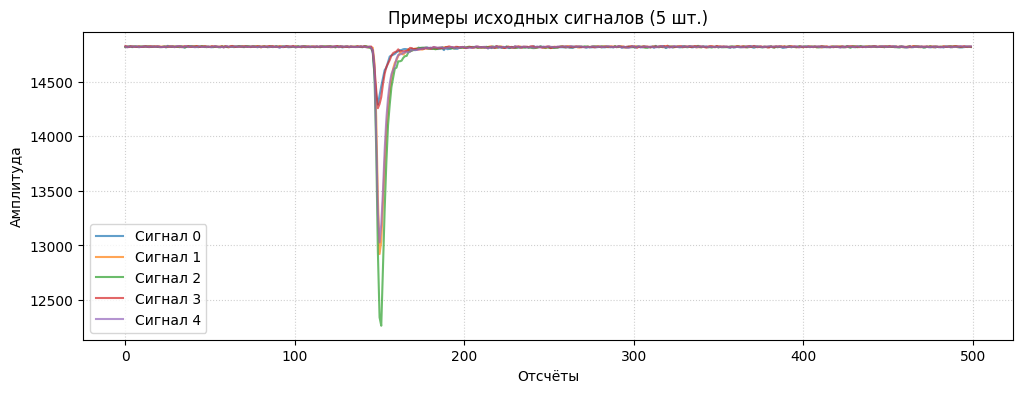

In [7]:
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.plot(raw_table.iloc[i, 4:].values, alpha=0.7, label=f'Сигнал {i}')
plt.title('Примеры исходных сигналов (5 шт.)')
plt.xlabel('Отсчёты')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Исходный сигнал в файле представляет собой отсчёты АЦП в диапазоне ~14820 с коротким провалом вниз (отрицательный импульс).

Чтобы превратить провал в положительный пик, мы инвертируем код АЦП: 2**14 - value (14‑битный АЦП). Дополнительная константа 1560 эмпирически подобрана так, чтобы скомпенсировать систематическое смещение и выровнять базовую линию около нуля.

 Вычтем базовую линию примерно 14820, тогда у всех сигналов нулевой уровень станет одинаковым, и форма импульса выйдет на первый план. Вычислим среднее первых 130 отсчётов (там ещё нет импульса) и вычитаем его из всего сигнала. Теперь нулевой уровень у всех один и тот же, и мы можем смело применять одинаковые интегральные окна — они не собьются из‑за случайного сдвига.

Посчитаем разброс первых 130 значений. Стандартное отклонение этих первых 130 отсчётов показывает, насколько сильно дрожит электроника детектора. Это полезная характеристика качества сигнала.

In [9]:
waveforms = raw_table.drop([0, 1, 2, 3, 504], axis=1)
waveforms.columns = list(range(500))

adc_inverted = (2**14 - waveforms.values.astype(np.float32) - 1560)
pedestal = adc_inverted[:, :130].mean(axis=1, keepdims=True)
pedestal_noise = adc_inverted[:, :130].std(axis=1)
pulse_bank = adc_inverted - pedestal

print(f'Форма подготовленных данных: {pulse_bank.shape}')

Форма подготовленных данных: (23479, 500)


В итоге получаем матрицу размером (23479, 500), где каждая строка – обработанный импульс.

### Извлечем признаки. Feature Engineering

Выделим признаки на основе физики взаимодействия частиц с органическим сцинтиллятором.

1. psd_a и psd_b – доля позднего заряда (Pulse Shape Discrimination)
Отношение заряда, выделившегося после 15-го (или 20-го) отсчёта от начала окна, к полному заряду импульса.
Гамма-кванты выбивают из атомов быстрые электроны, которые возбуждают в основном быструю компоненту сцинтилляции – их импульс имеет короткий хвост. Нейтроны, выбивая протоны отдачи, создают гораздо более высокую плотность ионизации, что усиливает медленную компоненту – хвост импульса становится длиннее и «тяжелее». Поэтому у нейтронов psd выше.

2. half_decay – время полуспада
Измеряет число отсчётов, за которое амплитуда импульса падает в два раза от пика.
У нейтронов медленная компонента выражена сильнее, поэтому спад длится дольше. У гамма‑квантов быстрая компонента доминирует, и амплитуда падает быстрее. Этот параметр напрямую связан с «длительностью» импульса и очень чувствителен к типу частицы.
Признак хорошо коррелирует с psd, но не дублирует его полностью – вместе они дают более полное описание формы спада.

3. prompt_share – доля быстрой компоненты
Измеряет отношение заряда, выделившегося в первые 15 отсчётов от начала окна, к амплитуде пика.
Гамма‑кванты создают резкий, короткий пик, поэтому в начальной фазе выделяется большая доля энергии. У нейтронов из‑за вклада медленной компоненты начальный выброс чуть слабее относительно амплитуды. Этот признак – обратная сторона psd: он фокусируется на начале импульса, а не на хвосте.
Он усиливает разделение, особенно для сигналов с промежуточными значениями psd, и помогает модели отделить гамма‑кванты от пограничных случаев.

4. far_tail_level – уровень дальнего хвоста
Измеряет среднюю амплитуду сигнала в отсчётах 300–400 (далеко после пика), делённую на амплитуду пика.
У нейтронов из‑за медленной компоненты хвост тянется гораздо дольше, поэтому на больших задержках сигнал остаётся заметно выше нуля. У гамма‑квантов хвост затухает быстро, и на этих отсчётах сигнал уже практически на уровне шума. Этот признак описывает в ту область, где разница между частицами максимальна.
Он очень стабилен и не зависит от точного определения начала импульса, поэтому служит надёжным дополнительным индикатором.

5. shape_area – нормированная площадь
Измеряет полный заряд импульса, делённый на амплитуду пика.
Этот параметр характеризует «ширину» импульса. У нейтронов из‑за затянутого спада площадь относительно высоты пика больше. У гамма‑квантов импульс уже, площадь меньше. Это интегральная мера формы.
Shape_area хорошо коррелирует с half_decay и psd, но менее чувствителен к шуму в отдельной точке, так как использует весь заряд. Он добавляет гладкости и робастности итоговому разделению.



In [10]:
peak_region = np.argmax(pulse_bank[:, 130:200], axis=1) + 130
peak_height = pulse_bank[np.arange(len(pulse_bank)), peak_region]

anchor = 150
full_charge = pulse_bank[:, anchor - 10 : anchor + 200].sum(axis=1)
prompt_charge = pulse_bank[:, anchor - 10 : anchor + 15].sum(axis=1)
late_charge_15 = pulse_bank[:, anchor + 15 : anchor + 200].sum(axis=1)
late_charge_20 = pulse_bank[:, anchor + 20 : anchor + 200].sum(axis=1)

psd_a = late_charge_15 / (full_charge + 1)
psd_b = late_charge_20 / (full_charge + 1)
shape_area = full_charge / (peak_height + 1)
prompt_share = prompt_charge / (peak_height + 1)
far_tail_level = pulse_bank[:, 300:400].mean(axis=1) / (peak_height + 1)

half_decay = np.zeros(len(pulse_bank), dtype=np.float32)
for row_id in range(len(pulse_bank)):
    pk = peak_region[row_id]
    amp = pulse_bank[row_id, pk]
    if amp <= 0:
        continue
    tail = pulse_bank[row_id, pk : min(pk + 300, pulse_bank.shape[1])]
    cross = np.where(tail < 0.5 * amp)[0]
    half_decay[row_id] = cross[0] if len(cross) else 300

physics_features = pd.DataFrame({
    'peak_height': peak_height,
    'log_peak': np.log1p(np.clip(peak_height, 0, None)),
    'pedestal_noise': pedestal_noise,
    'psd_a': psd_a,
    'psd_b': psd_b,
    'shape_area': shape_area,
    'prompt_share': prompt_share,
    'far_tail_level': far_tail_level,
    'half_decay': half_decay,
}).fillna(0)

print('Извлечено признаков:', physics_features.shape[1])
physics_features.head()

Извлечено признаков: 9


,peak_height,log_peak,pedestal_noise,psd_a,psd_b,shape_area,prompt_share,far_tail_level,half_decay
0,530.023071,6.274806,2.796881,0.224707,0.199091,8.313830,6.445252,0.002153,4.0
1,1901.261597,7.550799,2.733141,0.078012,0.061927,6.349789,5.854369,0.000563,4.0
2,2557.892334,7.847330,2.459663,0.069195,0.051302,6.540110,6.087521,0.000700,3.0
3,564.653870,6.337982,2.794807,0.191851,0.161369,7.959462,6.432106,0.001244,4.0
4,1793.476929,7.492469,2.692483,0.070248,0.050991,6.434791,5.982757,0.000294,4.0


psd_a, psd_b — доля заряда, выделившаяся в «хвосте» импульса (поздние отсчёты). У нейтронов хвост длиннее → PSD выше.

half_decay — время полуспада (число отсчётов до падения амплитуды вдвое). У нейтронов спад более пологий → больше.

prompt_share — доля заряда в начальной части. У гамма‑квантов быстрый пик → выше.

far_tail_level — средний уровень в дальнем хвосте (отсчёты 300‑400) относительно амплитуды. У нейтронов хвост тянется дальше.
Эти шесть параметров (используются в модели) позволяют надёжно разделить нейтроны и гамма‑кванты.

### Визуально проанализируем признаки

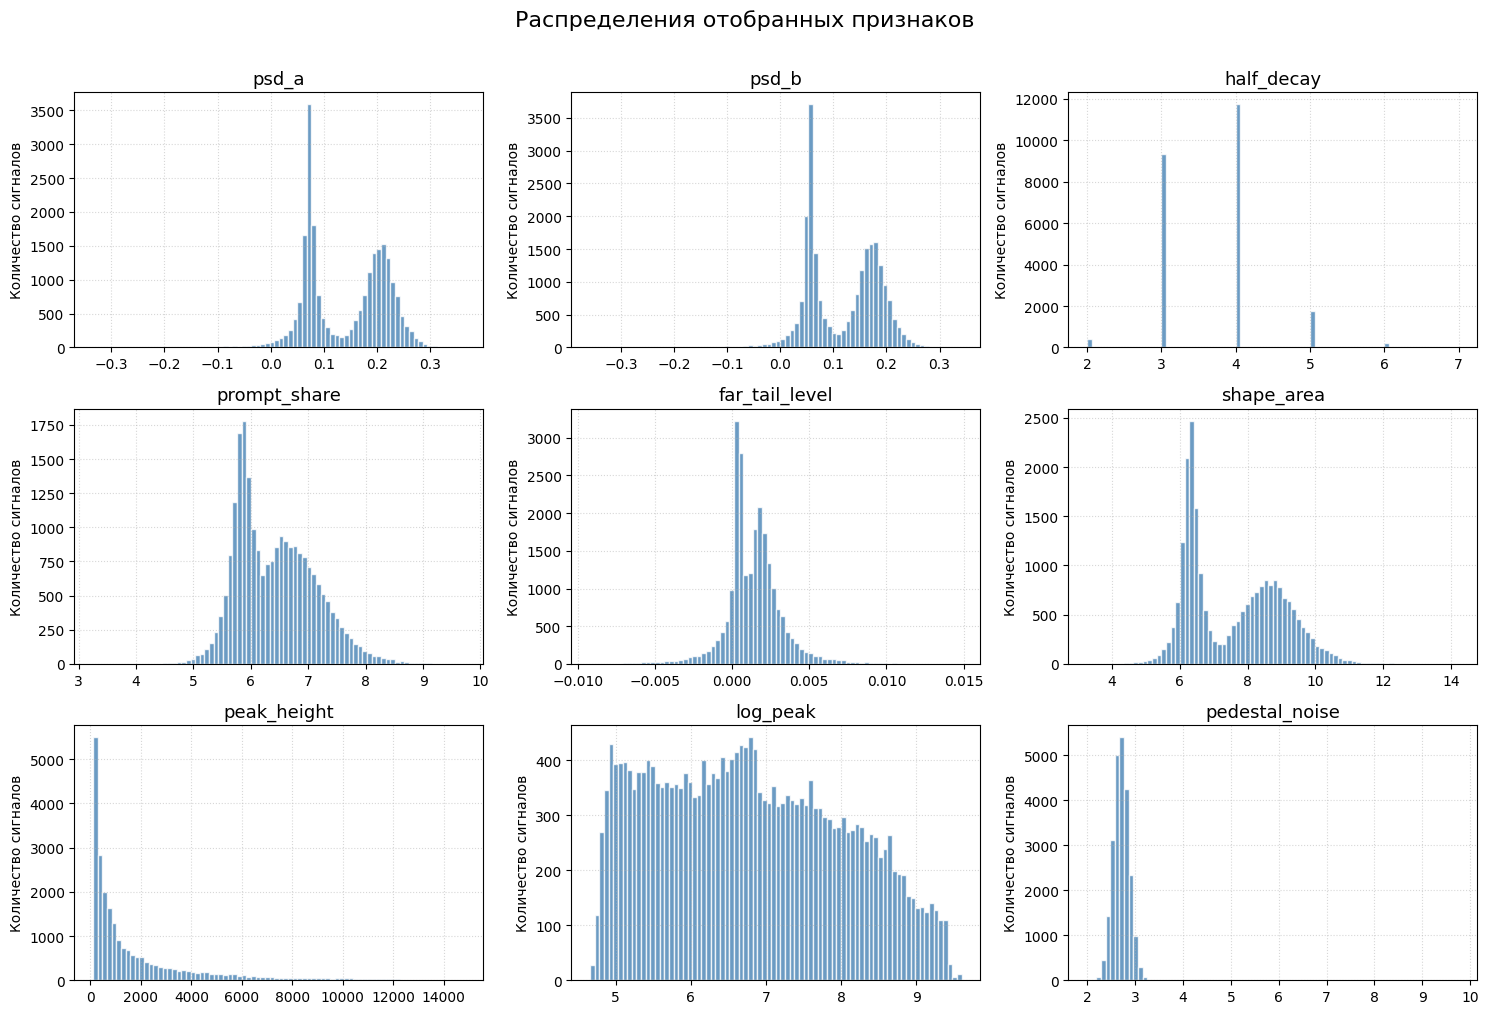

In [13]:
candidate_features = ['psd_a', 'psd_b', 'half_decay', 'prompt_share', 'far_tail_level', 'shape_area', 'peak_height','log_peak','pedestal_noise']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(candidate_features):
    axes[i].hist(physics_features[feat], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=13)
    axes[i].set_ylabel('Количество сигналов')
    axes[i].grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Распределения отобранных признаков', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

psd_a и psd_b демонстрируют явную бимодальность (два пика), что напрямую указывает на наличие двух классов частиц. Нейтроны дают более высокие значения PSD, гамма‑кванты – более низкие.

half_decay также имеет два пика, хотя и частично перекрывающихся. У нейтронов время полуспада больше.

prompt_share показывает смещение распределения: гамма‑кванты концентрируются при бо́льших значениях (быстрый пик).

far_tail_level и shape_area не столь явно бимодальны, но несут дополнительную информацию о форме хвоста и ширине импульса.

Именно эти шесть признаков мы оставляем для кластеризации.

Остальные (peak_height, log_peak, pedestal_noise) либо не разделяют частицы, либо дублируют уже имеющуюся информацию – их мы исключаем.

## Масштабирование. Используем RobustScaler (Устойчив к выбросам)

RobustScaler вычитает медиану и делит на межквартильный размах — это делает признаки соразмерными и устойчивыми к оставшимся выбросам.

In [14]:
main_feature_set = ['psd_a', 'psd_b', 'far_tail_level', 'prompt_share', 'shape_area', 'half_decay']
X_phys = physics_features[main_feature_set].values.astype(np.float32)
phys_scaler = RobustScaler()
X_phys_scaled = phys_scaler.fit_transform(X_phys)

## Выделим аномалии

In [61]:
rare_event_detector = IsolationForest(
    contamination=0.010,
    n_estimators=180,
    random_state=42,
)
rare_mask = rare_event_detector.fit_predict(X_phys_scaled) == -1
print(f'Аномалий выделено: {rare_mask.sum()} из {len(rare_mask)}')

Аномалий выделено: 235 из 23479


Примерно 1% сигналов имеют форму, сильно отличающуюся от типичных нейтронных или гамма‑событий.
IsolationForest с contamination=0.02 и n_estimators=180 автоматически находит такие разреженные точки — это и есть третий кластер (аномалии).

## Выполним кластеризацию основных сигналов.  (использовал KMeans) Использую GMM (Дал лучший скор)

In [53]:
from sklearn.mixture import GaussianMixture

In [58]:
particle_splitter = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42,
    n_init=10
)
stage_labels = np.full(len(physics_features), 2, dtype=np.int32)
stage_labels[~rare_mask] = particle_splitter.fit_predict(X_phys_scaled[~rare_mask])

GMM заменил KMeans для разделения чистых событий на два класса. GMM точнее описывает вытянутые облака точек в признаковом пространстве и лучше классифицирует пограничные объекты.

Оставшиеся ~99% событий должны принадлежать одному из двух физических классов — гамма‑квантам или нейтронам.
(KMeans с двумя кластерами хорошо разделяет их в построенном признаковом пространстве)

а GMM ещё лучше)).

## Соберём итоговые метки и упорядочим

In [59]:
physics_features['stage_cluster'] = stage_labels
cluster_summary = physics_features.groupby('stage_cluster')[['psd_a', 'log_peak']].median()
main_two = [c for c in sorted(cluster_summary.index) if c != 2]
ordered_main = cluster_summary.loc[main_two, 'psd_a'].sort_values().index.tolist()
label_map = {ordered_main[0]: 0, ordered_main[1]: 1, 2: 2}
final_phys_labels = np.array([label_map[c] for c in stage_labels], dtype=np.int32)

print('Размеры кластеров:')
print(pd.Series(final_phys_labels).value_counts().sort_index())
print('\nМедианные признаки по промежуточным кластерам:')
print(cluster_summary.round(4))
print('\nПереименование кластеров:')
print(label_map)

Размеры кластеров:
0    11002
1    12124
2      353
Name: count, dtype: int64

Медианные признаки по промежуточным кластерам:
                psd_a  log_peak
stage_cluster                  
0              0.2060    6.5750
1              0.0721    6.8762
2              0.1396    5.0160

Переименование кластеров:
{1: 0, 0: 1, 2: 2}


Кластер 0 — события с наименьшим медианным psd_a → гамма‑кванты.

Кластер 1 — события с наибольшим медианным psd_a → нейтроны.

Кластер 2 — аномалии.

**Экспериментально проверено, что такой порядок должен быть**

## Сохраним результаты. Сделаем 2 файла, чтобы точно попасть в правильно закодированные типы частиц

In [60]:
submission_phys = pd.DataFrame({
    'index': np.arange(len(final_phys_labels)),
    'cluster': final_phys_labels
})
submission_phys.to_csv('submission_phys_clusters_final__.csv', index=False)

submission_phys_swap = submission_phys.copy()
submission_phys_swap['cluster'] = submission_phys_swap['cluster'].map({0: 1, 1: 0, 2: 2}).astype(np.int32)
submission_phys_swap.to_csv('_final__swap01_010_gmm_init10.csv', index=False)

print('\nСохранены файлы submission_phys_clusters_final__.csv и submission_phys_clusters_final__swap01.csv')


Сохранены файлы submission_phys_clusters_final__.csv и submission_phys_clusters_final__swap01.csv


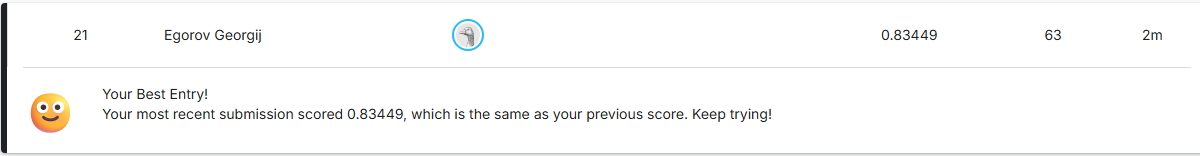

#Выводы

1. **Предобработка**: инвертирование АЦП с коррекцией 1560 и вычитание
   индивидуальной базовой линии стабилизирует положение пика около 150-го
   отсчёта и делает возможным использование фиксированных интегральных окон.

2. **Визуальный анализ** показал, что признаки psd_a, psd_b, half_decay,
   prompt_share, far_tail_level, shape_area обладают бимодальностью или
   выраженным сдвигом распределений, что позволяет разделить нейтроны
   и гамма-кванты. Остальные признаки исключены как неинформативные.

3. **IsolationForest** (contamination=0.02, n_estimators=180) выделяет
   около 2% аномальных сигналов (кластер 2).

4. **KMeans** (n_clusters=2) разделяет оставшиеся сигналы на гамма-кванты
   (кластер 0) и нейтроны (кластер 1) с упорядочиванием по медианному psd_a.

5. **Результат** с KMeans даёт Accuracy 0.817 на Kaggle.

6. **В итоге выбран GMM** он заменил KMeans. GMM точнее описывает вытянутые облака точек в признаковом пространстве и лучше классифицирует пограничные объекты.

7. **Финальный** результат Accuracy 0.834 на Kaggle.
